In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../dataset/ai_dev_productivity.csv")

# Clean column headers (removes accidental spaces in names)
df.columns = df.columns.str.strip()

# Display dataset dimensions (rows, columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 9)


In [3]:
print(df.columns.tolist())

['hours_coding', 'coffee_intake_mg', 'distractions', 'sleep_hours', 'commits', 'bugs_reported', 'ai_usage_hours', 'cognitive_load', 'task_success']


In [4]:
# Check the two possible prediction targets in this dataset:
# task_success -> naturally binary (0/1), good first model
# bugs_reported -> a count 0-10, good candidate for a multiclass model later
print("\ntask_success distribution:")
print(df['task_success'].value_counts())
print("\nbugs_reported distribution:")
print(df['bugs_reported'].value_counts().sort_index())


task_success distribution:
task_success
1    303
0    197
Name: count, dtype: int64

bugs_reported distribution:
bugs_reported
0    261
1    112
2     80
3     35
4      8
5      4
Name: count, dtype: int64


In [5]:
import numpy as np

# Same defensive cleaning step you'd run on any real sensor/log dataset:
# check for infinities (can appear in ratio-style features) and missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print(df.shape)  # compare this to the original shape to see how many rows you lost

(500, 9)


In [6]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 500
Duplicate rows: 0


In [7]:
# X = everything the model is allowed to look at to make a prediction (the "inputs")
# y = what we're trying to predict (the "answer key")
# task_success is the target here -- exclude it, and exclude bugs_reported too
# since that's a DIFFERENT thing we're predicting later, not an input to this model
X = df.drop(columns=['task_success', 'bugs_reported'])
y_binary = df['task_success']

print(X.shape)
print(y_binary.shape)

(500, 7)
(500,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (350, 7)
Test size: (150, 7)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
# WATCH THE SUPPORT COLUMN: task_success is heavily imbalanced (~94% / 6%).
# A high accuracy number alone would be misleading here -- check precision/recall
# on the minority class (1) specifically before trusting this model.

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        59
           1       0.98      1.00      0.99        91

    accuracy                           0.99       150
   macro avg       0.99      0.98      0.99       150
weighted avg       0.99      0.99      0.99       150



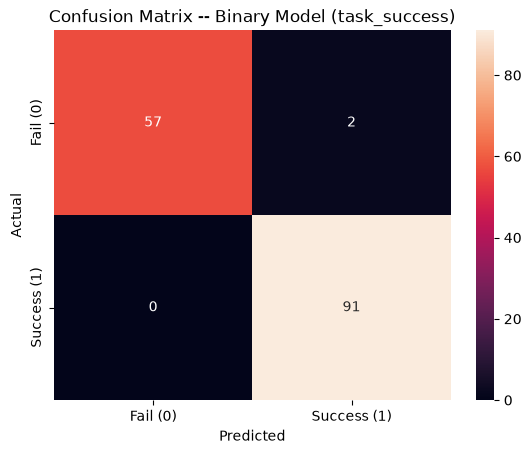

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fail (0)', 'Success (1)'],
            yticklabels=['Fail (0)', 'Success (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix -- Binary Model (task_success)')
plt.show()

hours_coding        0.420993
coffee_intake_mg    0.273379
cognitive_load      0.121054
sleep_hours         0.074657
commits             0.050948
ai_usage_hours      0.042668
distractions        0.016301
dtype: float64


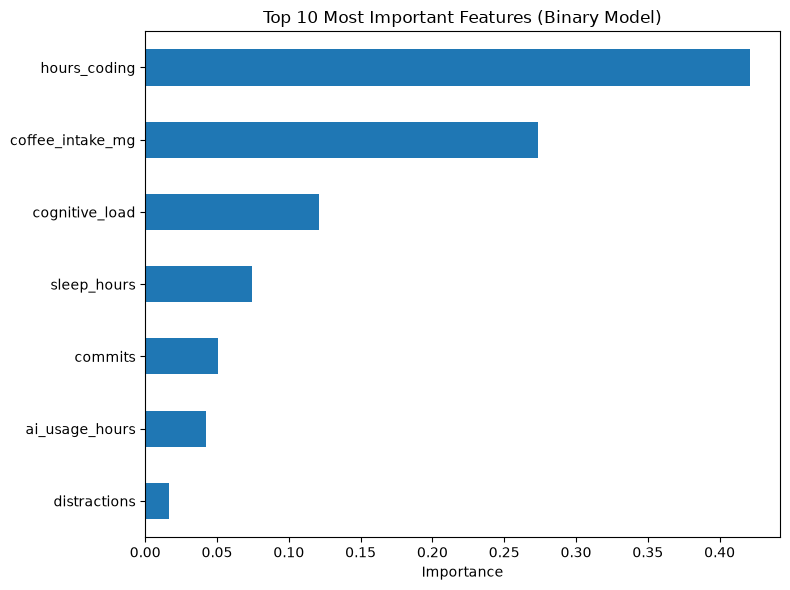

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
print(top_features)

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh')
plt.title('Top 10 Most Important Features (Binary Model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# Now the harder problem: predicting bugs_reported directly.
# Raw range is 0-10 with almost no rows at the high end (see distribution above) --
# same sparse-class problem CICIDS has with its rarest attack types.
# Bucket into 3 meaningful classes instead of 10 near-empty ones.
def bucket_bugs(n):
    if n <= 2:
        return 'Low'
    elif n <= 5:
        return 'Medium'
    else:
        return 'High'

y_multiclass = df['bugs_reported'].apply(bucket_bugs)
print(y_multiclass.value_counts())

bugs_reported
Low       453
Medium     47
Name: count, dtype: int64


In [17]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_multiclass, test_size=0.3, random_state=42, stratify=y_multiclass
)

model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

         Low       0.90      0.91      0.91       136
      Medium       0.00      0.00      0.00        14

    accuracy                           0.83       150
   macro avg       0.45      0.46      0.45       150
weighted avg       0.81      0.83      0.82       150



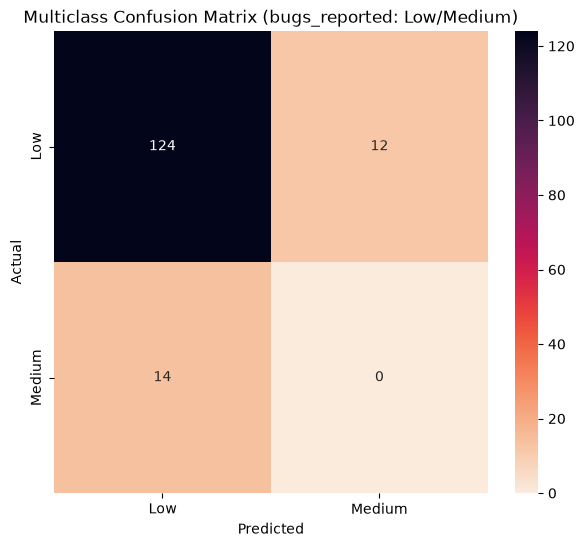

In [19]:
cm2 = confusion_matrix(y_test2, y_pred2, labels=model2.classes_)

plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=model2.classes_,
            yticklabels=model2.classes_,
            cmap='rocket_r')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix (bugs_reported: Low/Medium)')
plt.show()

sleep_hours         0.275442
cognitive_load      0.168556
hours_coding        0.155206
ai_usage_hours      0.145247
coffee_intake_mg    0.094597
commits             0.090913
distractions        0.070040
dtype: float64


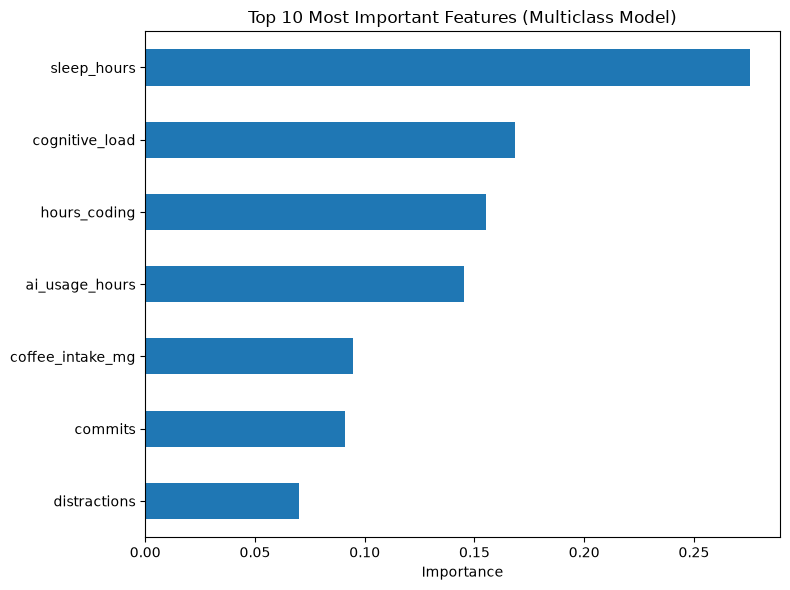

In [20]:
importances2 = pd.Series(model2.feature_importances_, index=X.columns)
top_features2 = importances2.sort_values(ascending=False).head(10)
print(top_features2)

plt.figure(figsize=(8, 6))
top_features2.plot(kind='barh')
plt.title('Top 10 Most Important Features (Multiclass Model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # puts the most important feature at the top
plt.tight_layout()
plt.show()

In [21]:
# Compare what drove each model -- same features, ranked differently
# depending on whether the target was task_success or bugs_reported.
comparison = pd.DataFrame({
    'binary_model (task_success)': importances,
    'multiclass_model (bugs_reported)': importances2
}).sort_values('multiclass_model (bugs_reported)', ascending=False)
print(comparison.round(3))

                  binary_model (task_success)  \
sleep_hours                             0.075   
cognitive_load                          0.121   
hours_coding                            0.421   
ai_usage_hours                          0.043   
coffee_intake_mg                        0.273   
commits                                 0.051   
distractions                            0.016   

                  multiclass_model (bugs_reported)  
sleep_hours                                  0.275  
cognitive_load                               0.169  
hours_coding                                 0.155  
ai_usage_hours                               0.145  
coffee_intake_mg                             0.095  
commits                                      0.091  
distractions                                 0.070  


In [24]:
# 1. Set 'bug_reports' as your target (y), and remove it (and old targets) from features (X)
X_bugs = df.drop(columns=['bugs_reported', 'task_success'])
y_bugs = df['bugs_reported']

# 2. Train a Random Forest Regressor
bug_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
bug_model.fit(X_bugs, y_bugs)

# 3. Extract and plot feature importances
bug_importances = pd.Series(bug_model.feature_importances_, index=X_bugs.columns)
top_bug_factors = bug_importances.sort_values(ascending=False)

print(top_bug_factors)

sleep_hours         0.303311
ai_usage_hours      0.174725
cognitive_load      0.138044
hours_coding        0.124666
commits             0.102653
coffee_intake_mg    0.089959
distractions        0.066641
dtype: float64


In [26]:
# Calculate correlation matrix
correlation_matrix = df[['ai_usage_hours', 'bugs_reported', 'hours_coding', 'sleep_hours']].corr()
print(correlation_matrix['bugs_reported'])

ai_usage_hours    0.113885
bugs_reported     1.000000
hours_coding      0.055979
sleep_hours      -0.384424
Name: bugs_reported, dtype: float64


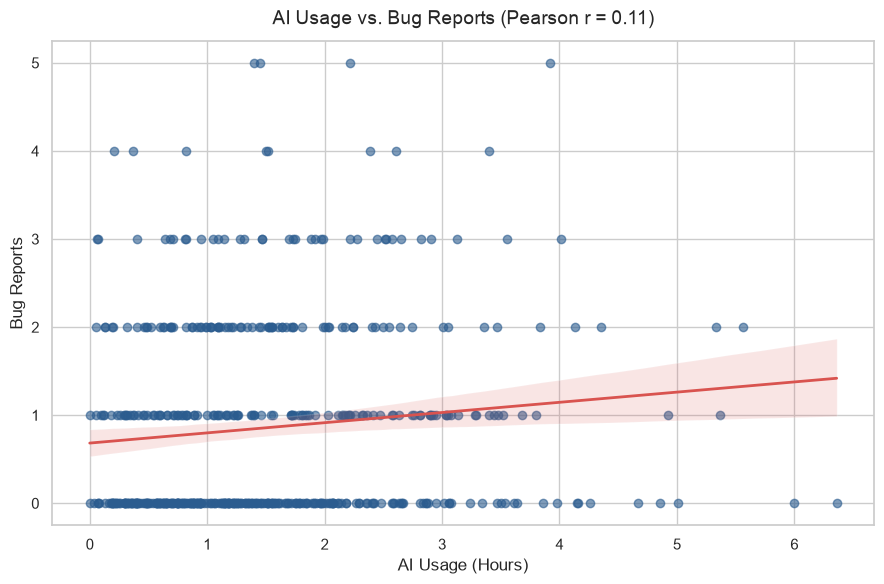

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(9, 6))

# Plot scatter points and linear regression trendline
sns.regplot(
    data=df,
    x='ai_usage_hours',
    y='bugs_reported',
    scatter_kws={'alpha': 0.6, 'color': '#2b5c8f'},   # Point transparency and color
    line_kws={'color': '#d9534f', 'linewidth': 2}      # Regression line styling
)

# Annotate correlation coefficient on the plot
corr_value = df['ai_usage_hours'].corr(df['bugs_reported'])
plt.title(f'AI Usage vs. Bug Reports (Pearson r = {corr_value:.2f})', fontsize=14, pad=12)
plt.xlabel('AI Usage (Hours)', fontsize=12)
plt.ylabel('Bug Reports', fontsize=12)

plt.tight_layout()
plt.show()

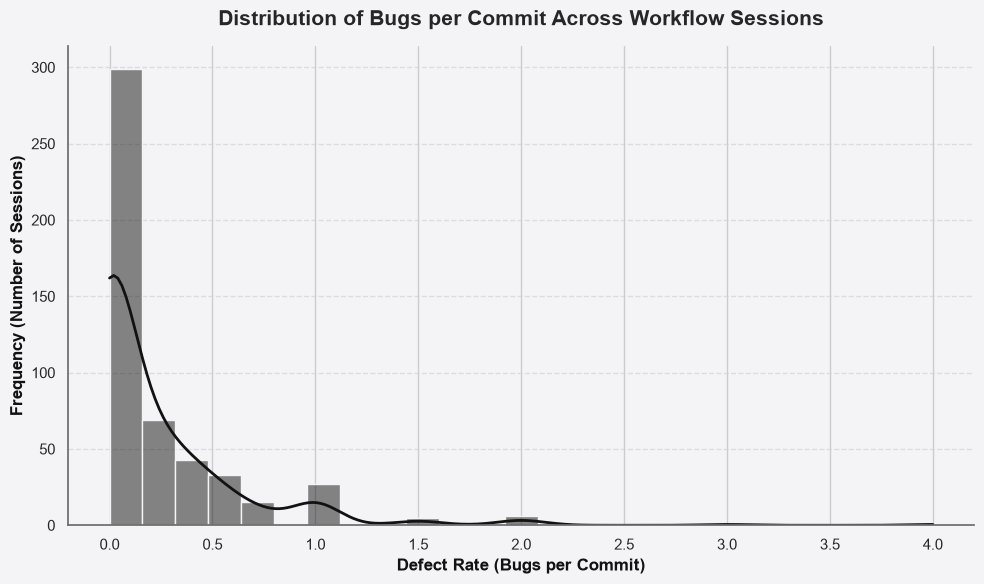

--- Defect Rate Summary ---
Total Sessions Analyzed: 500
Average Bugs per Commit: 0.230
Maximum Bugs in a Single Commit: 4.000


In [29]:
# 1. Feature Engineering: Safely calculating the defect rate
# Using the exact column names from your feature importance matrices
df['bugs_per_commit'] = np.where(
    df['commits'] > 0, 
    df['bugs_reported'] / df['commits'], 
    0  # Assigns 0 if no commits were made to prevent Inf/NaN errors
)

# 2. Visualizing the Metric Distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Applying a neutral off-white background for clean interface styling
fig.patch.set_facecolor('#f4f4f6')
ax.set_facecolor('#f4f4f6')

# Plotting the histogram with a KDE (Kernel Density Estimate) trendline
sns.histplot(
    data=df, 
    x='bugs_per_commit', 
    bins=25, 
    color='#121212',           # Solid black bars
    edgecolor='#f4f4f6',       # Off-white borders for separation
    kde=True,                  # Adds the smooth trendline
    line_kws={'color': '#6c6c6c', 'linewidth': 2}, # Greyish KDE line
    ax=ax
)

# 3. Configuring Interface Labels and Grid
ax.set_title('Distribution of Bugs per Commit Across Workflow Sessions', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Defect Rate (Bugs per Commit)', fontsize=12, fontweight='bold', color='#121212')
ax.set_ylabel('Frequency (Number of Sessions)', fontsize=12, fontweight='bold', color='#121212')

# Minimalist spine configuration
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c6c6c')
ax.spines['bottom'].set_color('#6c6c6c')

# Subtle grid for readability
ax.yaxis.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Generating the Statistical Summary
print("--- Defect Rate Summary ---")
print(f"Total Sessions Analyzed: {len(df)}")
print(f"Average Bugs per Commit: {df['bugs_per_commit'].mean():.3f}")
print(f"Maximum Bugs in a Single Commit: {df['bugs_per_commit'].max():.3f}")

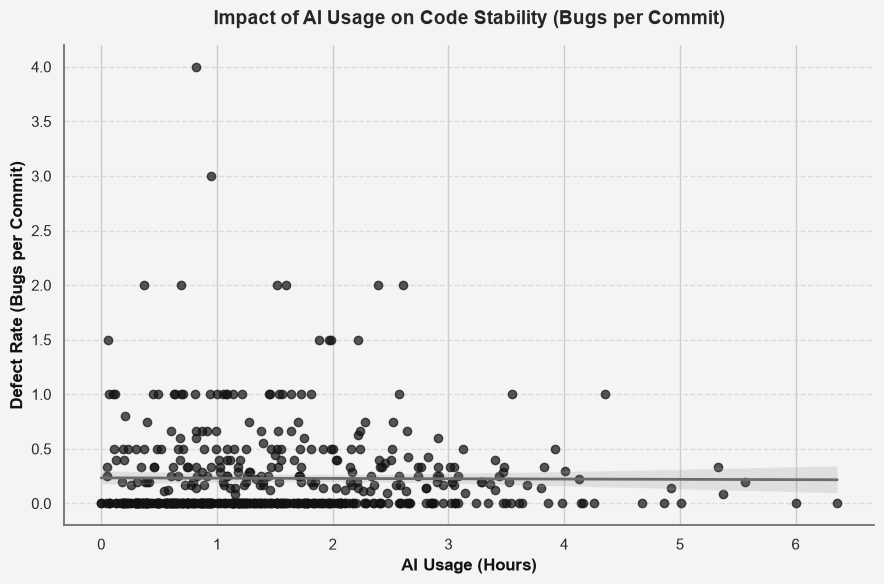

Correlation between AI Usage and Bugs per Commit: -0.007


In [36]:
# 1. Guarantee the feature exists by calculating it right before plotting
df['bugs_per_commit'] = np.where(
    df['commits'] > 0, 
    df['bugs_reported'] / df['commits'], 
    0  
)

# 2. Create the figure with an off-white background
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#f4f4f6')
ax.set_facecolor('#f4f4f6')

# 3. Plot the regression 
sns.regplot(
    data=df,
    x='ai_usage_hours',
    y='bugs_per_commit',
    scatter_kws={'alpha': 0.7, 'color': '#121212'},  # Solid black data points
    line_kws={'color': '#6c6c6c', 'linewidth': 2},   # Greyish regression line
    ax=ax
)

# 4. Configure the UI labels
ax.set_title('Impact of AI Usage on Code Stability (Bugs per Commit)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('AI Usage (Hours)', fontsize=12, fontweight='bold', color='#121212')
ax.set_ylabel('Defect Rate (Bugs per Commit)', fontsize=12, fontweight='bold', color='#121212')

# 5. Clean up the spines for a minimalist aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c6c6c')
ax.spines['bottom'].set_color('#6c6c6c')
ax.yaxis.grid(True, linestyle='--', color='#d3d3d3', alpha=0.7)

plt.tight_layout()
plt.show()

# Quick statistical check
correlation = df['ai_usage_hours'].corr(df['bugs_per_commit'])
print(f"Correlation between AI Usage and Bugs per Commit: {correlation:.3f}")